In [133]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Local packages
from etc.hamiltonian import Hamiltonian
from etc_utils.graph_models import *
from etc_utils.phase_diagrams import *

### Hamiltonian Equation
 We pretend to find the minimun for a given set of nodes k and parameters $\mu/\gamma$

$$
H(S) = \sum_{j<i}-\mu A_{ij} s_i s_j + \gamma \frac{s_i s_j (1-A_{ij})}{d_{i,j}²}
$$


### Import all graphs examples
Once this is predifine we upload the example graphs 

In [134]:
Gs = get_graphs_list()

I will test hamiltonian.py class in here

In [ ]:
G1 = Gs[0][1]  

In [136]:
H1 = Hamiltonian(G1)

In [141]:
H1.n

25

In [146]:
pos = H1.Dinv2_triu[H1.Dinv2_triu > 0.0]
if pos.size > 0:
    print(float(pos.min()))

0.015625


In [150]:
H1.Dinv2_triu[H1.Dinv2_triu > 0.0].size

300

In [152]:
H1.compute([0, 15, 2], mu=0.5,gamma=0.5)

(0.010204081632653073, -0.5, 0.5102040816326531)

In [21]:
def plot_phase_diagram(result: dict, *, cmap='viridis', interpolation='bilinear',
                        show_contours=True, contour_levels=8, annotate_crit=True,
                        save_path: str = None):
    """
    Improved phase-diagram plotting helper.

    Features:
    - Sorts keys for consistent axes
    - Better x/y ticks and labels (uses raw strings to avoid escape warnings)
    - Optional contour overlay and automatic critical-point highlighting
    - Optional saving and returns (fig, ax)
    """
    if not result:
        raise ValueError("The result dictionary is empty.")

    # Use sorted keys so axes increase monotonically
    k_values = sorted(list(result.keys()))
    if not all(isinstance(k, (int, float)) for k in k_values):
        raise ValueError("Keys of the result dictionary must be numeric (e.g., int or float).")

    scale_values = sorted(list(result[k_values[0]].keys()))
    if not all(isinstance(scale, (int, float)) for scale in scale_values):
        raise ValueError("Scale values in the result dictionary must be numeric (e.g., int or float).")

    mu_gamma_list = []
    hmin_list = []
    for k in k_values:
        for scale in scale_values:
            ratio, hmin = result[k][scale]
            mu_gamma_list.append(ratio)
            hmin_list.append(hmin)

    # Reshape into 2D arrays with shape (len(k_values), len(scale_values))
    try:
        mu_gamma_arr = np.array(mu_gamma_list).reshape(len(k_values), len(scale_values))
        hmin_arr = np.array(hmin_list).reshape(len(k_values), len(scale_values))
    except ValueError as e:
        raise ValueError(
            "Mismatch in the dimensions of the result data. Ensure the data is consistent."
            ) from e

    # x coordinates (one value per column), y coordinates (one per row)
    x_vals = mu_gamma_arr[0, :].astype(float)
    y_vals = np.array(k_values, dtype=float)

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Use imshow for a quick heatmap, but set extent so x axis maps to mu/gamma values
    extent = [x_vals.min(), x_vals.max(), y_vals.min() - 0.5, y_vals.max() + 0.5]
    im = ax.imshow(hmin_arr, aspect='auto', origin='lower', interpolation=interpolation,
                   cmap=cmap, extent=extent)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('H_min')

    # Axis labels (use raw strings to avoid invalid escape sequence warnings)
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$k$')
    ax.set_title('Phase Diagram')

    # X ticks: one per scale column (show at most 12 labels to avoid overlap)
    max_xticks = 12
    if len(x_vals) <= max_xticks:
        xt_positions = x_vals
        xt_labels = [f'{v:.3g}' for v in x_vals]
    else:
        idxs = np.linspace(0, len(x_vals) - 1, max_xticks, dtype=int)
        xt_positions = x_vals[idxs]
        xt_labels = [f'{v:.3g}' for v in x_vals[idxs]]
    ax.set_xticks(xt_positions)
    ax.set_xticklabels(xt_labels, rotation=45, ha='right')

    # Y ticks: show the k values
    ax.set_yticks(y_vals)
    ax.set_yticklabels([str(int(v)) if float(v).is_integer() else f'{v:.2g}' for v in y_vals])

    # Optional contour overlay to highlight level sets
    if show_contours:
        Xc, Yc = np.meshgrid(x_vals, y_vals)
        cs = ax.contour(Xc, Yc, hmin_arr, levels=contour_levels, colors='white', linewidths=0.7, alpha=0.8)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%.2g')

    # Annotate critical points using gradient along k (rows)
    if annotate_crit:
        grad = np.gradient(hmin_arr, axis=0)
        thresh = np.percentile(np.abs(grad), 95)
        crit_idx = np.where(np.abs(grad) > thresh)
        if crit_idx[0].size > 0:
            xs = x_vals[crit_idx[1]]
            ys = y_vals[crit_idx[0]]
            ax.scatter(xs, ys, c='red', s=18, label='Critical (top 5%)')
            ax.legend(loc='upper right')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    return fig, ax

1. First example
## Barbell graph (c=25, p=5)
* Nodes: $n=25$
* Edges: $e = 96$
* Nodes in the path : 5
##### Is the composition of 2 chiques connected by a line

Uncomment the line below to visualize the graph

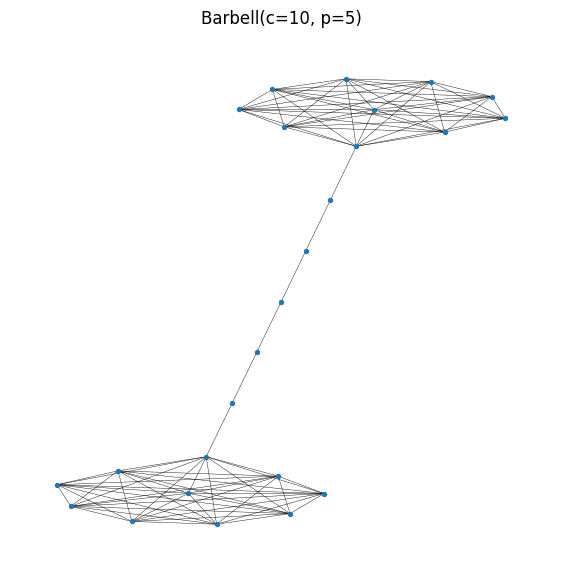

In [123]:
show_graph(Gs[0][1], title=Gs[0][0])

### Hamiltonian and graph atributes
$$\mu = 1 - \rho$$
where $\rho$ is
$$\rho = \frac{2e}{n(n-1)}$$

In [124]:
H1 = Hamiltonian(Gs[0][1])
# parameter mu predefined
mu=H1.mu_density_aware(G=Gs[0][1])
# parameter gamma predefined
gamma=H1.gamma_balancer(mu=mu)
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[0][1]))
# Inverse of distance matrix upper triangle
D2 = H1.Dinv2_triu

25

In [86]:
gamma/mu

30.117647058823533

In [84]:
G1_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H1,
    mu=1,
    gamma=1,
    kmax=int(7),
    scale_max=31,
    scale_steps=1,
    k_steps=1
)

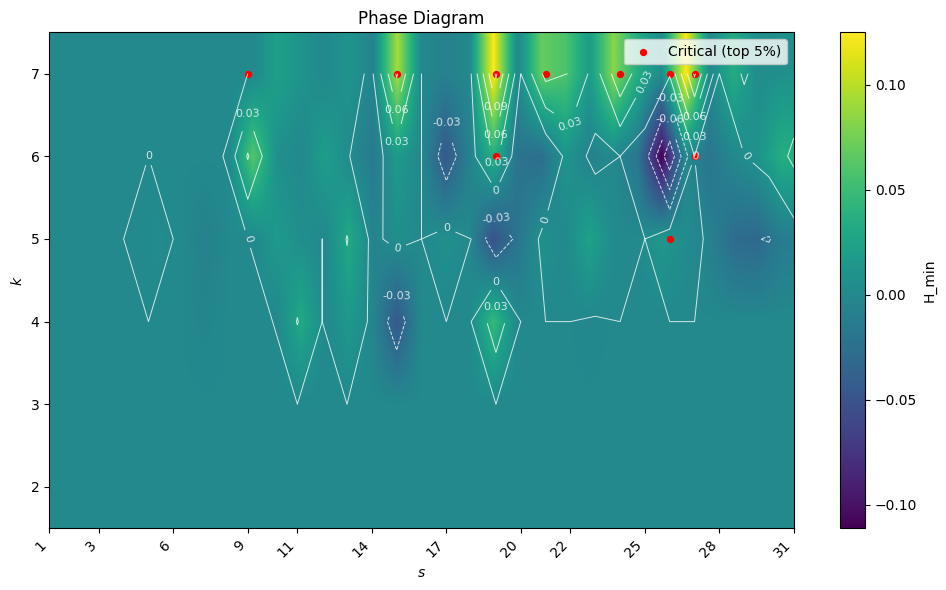

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$s$', ylabel='$k$'>)

In [85]:
plot_phase_diagram(G1_pd)

In [7]:
#save values of G1_pd
np.save('G1_pd.npy', G1_pd)

In [46]:
G1_pd = np.load('G1_pd.npy', allow_pickle=True)

In [8]:
# # Compute gradients to identify critical points
# hmin_gradients = np.gradient(hmin_values, axis=0)
# critical_points = np.abs(hmin_gradients) > np.percentile(np.abs(hmin_gradients), 95)  # Top 5% changes

# # Overlay critical points on the phase diagram
# plt.figure(figsize=(10, 6))
# plt.imshow(hmin_values, aspect='auto', origin='lower',
#            extent=[mu_gamma_ratios.min(), mu_gamma_ratios.max(),
#                   min(k_values), max(k_values)], cmap='viridis')
# plt.colorbar(label='H_min')
# plt.xlabel('$\mu / \gamma$')
# plt.ylabel('$k$')
# plt.title('Phase Diagram with Critical Points')

# # Highlight critical points
# critical_k, critical_mu_gamma = np.where(critical_points)
# plt.scatter(mu_gamma_ratios[critical_k, critical_mu_gamma],
#             np.array(k_values)[critical_k], color='red', s=10, label='Critical Points')
# plt.legend()
# plt.show()

2. Second Example
## Balance Tree (ramifications=3, height=4)
* Nodes: $n = 121$
* Edges: $e = 120$
##### The left and right subtrees of any node are the same height

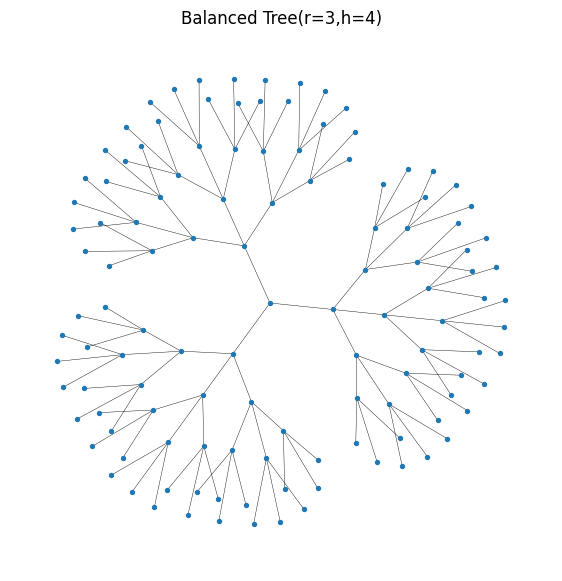

In [47]:
show_graph(Gs[4][1], title=Gs[4][0])

In [48]:
H4 = Hamiltonian(Gs[4][1])
# parameter mu predefined
mu=1
# parameter gamma predefined
gamma=1
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[4][1]))
# Inverse of distance matrix upper triangle
D2 = H4.Dinv2_triu

In [54]:
G4_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H4,
    mu=mu,
    gamma=gamma,
    kmax=int(40),
    scale_max=5,
    scale_steps=1,
    k_steps=5
)

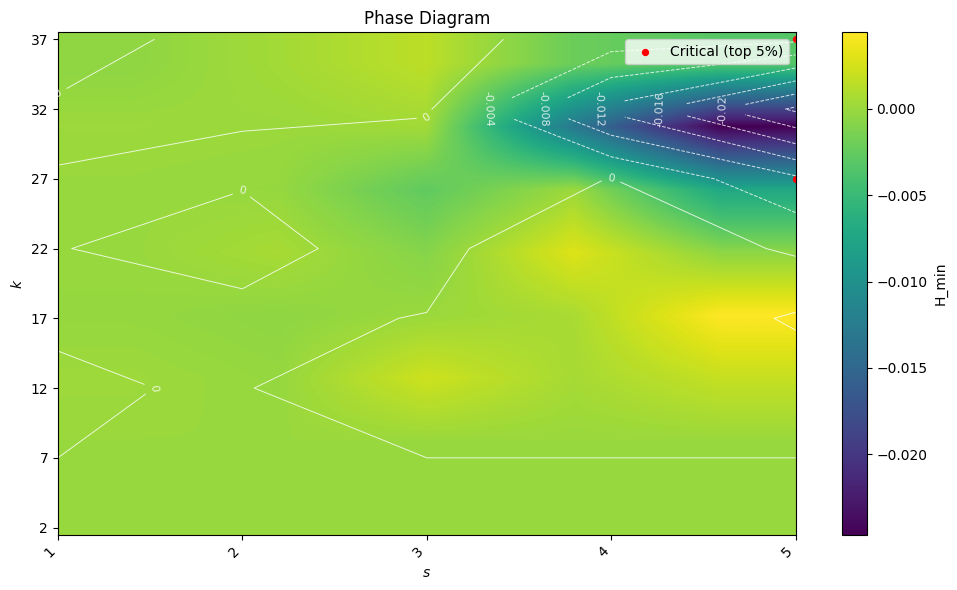

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$s$', ylabel='$k$'>)

In [55]:
plot_phase_diagram(G4_pd)

## Random Partition communities
* Nodes: $n = 45$
* Edges: $e = 283$
#### A graph of communities with sizes defined by s in sizes. 

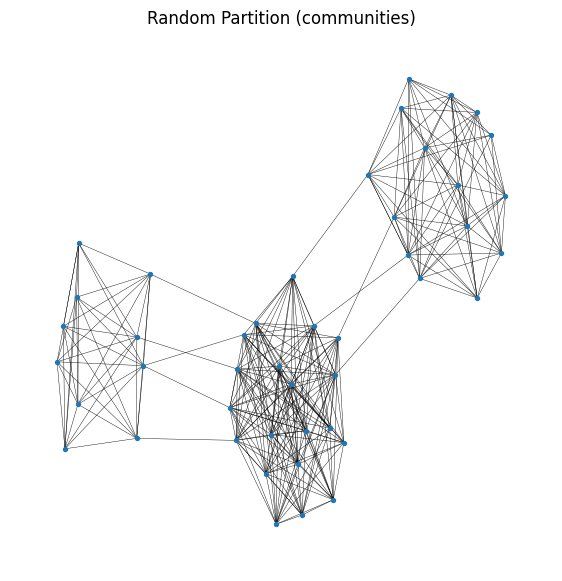

In [56]:
show_graph(Gs[7][1], title=Gs[7][0])

In [58]:
H7 = Hamiltonian(Gs[7][1])
# parameter mu predefined
mu=1
# parameter gamma predefined
gamma=1
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[7][1]))
# Inverse of distance matrix upper triangle
D2 = H7.Dinv2_triu

In [61]:
G7_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H7,
    mu=mu,
    kmax=int(15),
    scale_max=int(15),
    scale_steps=1,
    k_steps=1
)

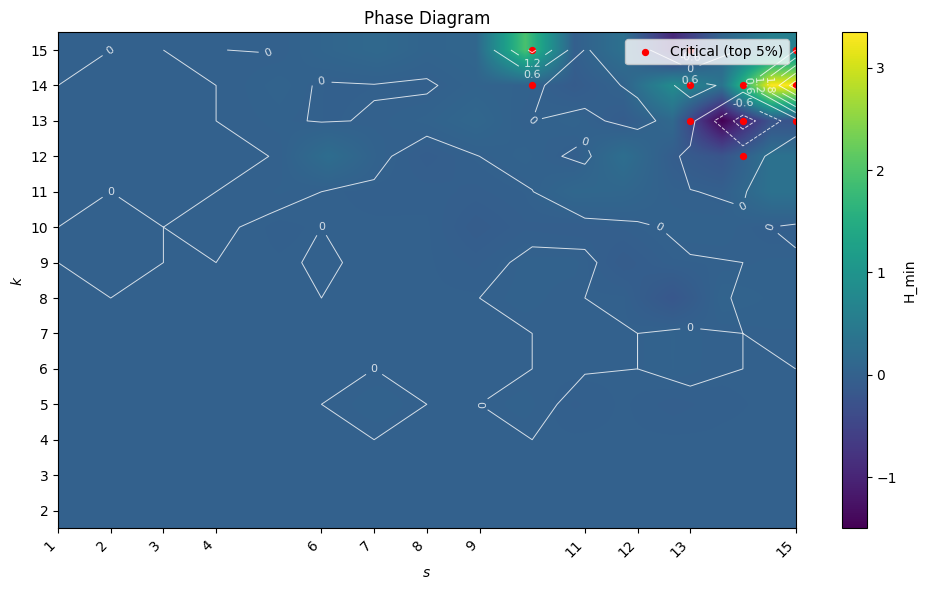

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$s$', ylabel='$k$'>)

In [62]:
plot_phase_diagram(G7_pd)

## Erdos-Renyi (n=80, p=0.05)
* Nodes: $n = 80$
* Edges: $e = 156$
##### A random graph which connects each pair of nodes {i,j} with probability p, independent

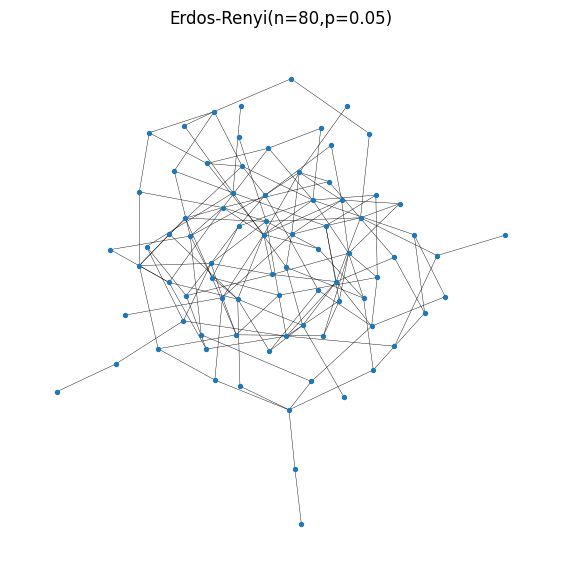

In [72]:
show_graph(Gs[6][1], title=Gs[6][0])

In [63]:
H6 = Hamiltonian(Gs[6][1])
# parameter mu predefined
mu=1
# parameter gamma predefined
gamma=1
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[6][1]))
# Inverse of distance matrix upper triangle
D2 = H6.Dinv2_triu

In [65]:
G6_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H6,
    mu=mu,
    kmax=int(35),
    scale_max=5,
    scale_steps=1,
    k_steps=1
)

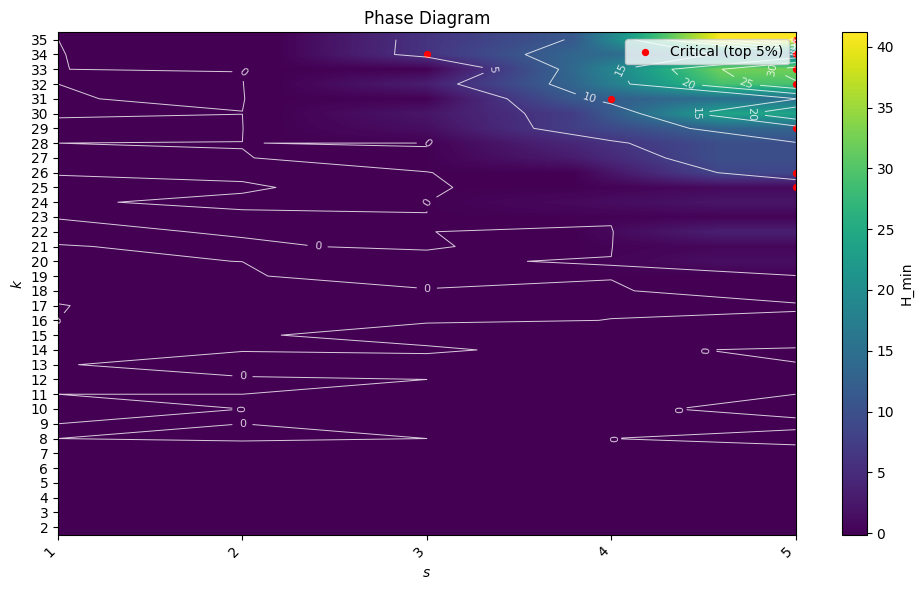

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$s$', ylabel='$k$'>)

In [66]:
plot_phase_diagram(G6_pd)

## 6D Regular (nodes=50, degree=6)
* Nodes: $n = 50$
* Edges: $e = 150$
##### Regular graph with 50 nodes where all nodes have degree 6

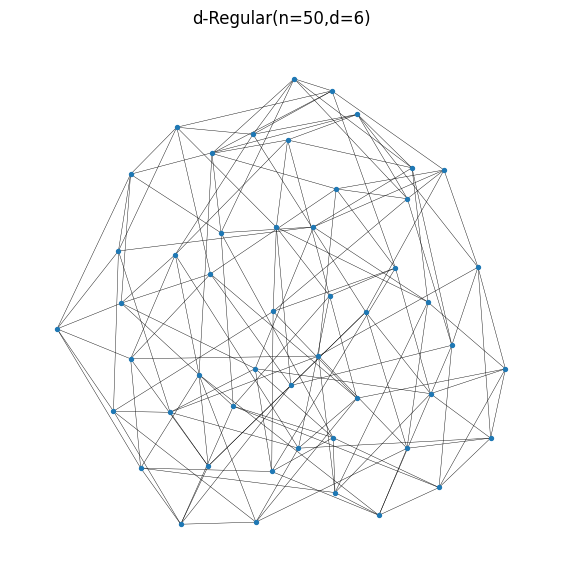

In [71]:
show_graph(Gs[-3][1], title=Gs[-3][0])

In [67]:
H17 = Hamiltonian(Gs[-3][1])
# parameter mu predefined
mu=H17.mu_density_aware(G=Gs[-3][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[-3][1]))
# Inverse of distance matrix upper triangle
D2 = H17.Dinv2_triu

In [68]:
G17_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H17,
    mu=mu,
    kmax=int(20),
    scale_max=int(20),
    scale_steps=1,
    k_steps=1
)

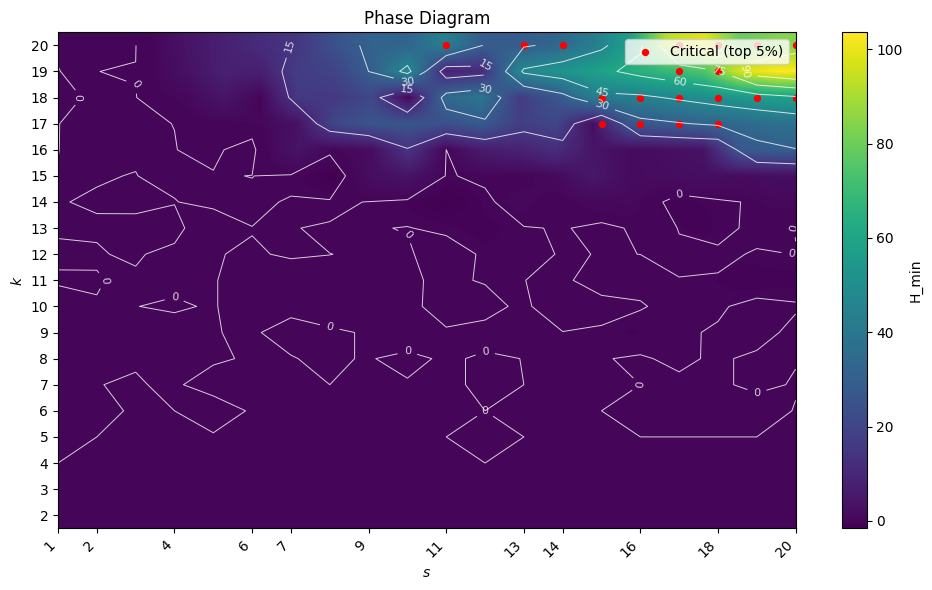

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$s$', ylabel='$k$'>)

In [69]:
plot_phase_diagram(G17_pd)

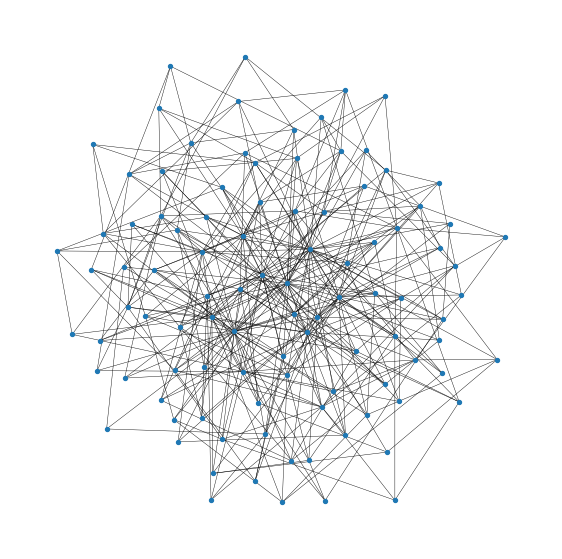

In [81]:
show_graph(nx.barabasi_albert_graph(100, 4))

In [88]:
import itertools
from scipy.stats import gaussian_kde

In [108]:
k = 4
n_samples = 50
seed = 42

G1 = Gs[0][1]
rng = np.random.default_rng(seed)

In [114]:
Hs = np.empty(n_samples, dtype=float)
for t in range(n_samples):
    S = rng.choice(H1.n, size=k, replace=False)
    Hs[t] = H1.compute(S, A, D2)[0]

ValueError: setting an array element with a sequence.

In [119]:
H1.compute(S, A, D2)[0]

array([[ 0.        , -0.90972222, -0.90972222, -0.90972222, -0.90972222,
        -0.90972222, -0.90972222, -0.90972222, -0.90972222, -0.90972222,
         0.27256944,  0.12114198,  0.06814236,  0.04361111,  0.03028549,
         0.02225057,  0.01703559,  0.01703559,  0.01703559,  0.01703559,
         0.01703559,  0.01703559,  0.01703559,  0.01703559,  0.01703559],
       [ 0.        ,  0.        , -0.90972222, -0.90972222, -0.90972222,
        -0.90972222, -0.90972222, -0.90972222, -0.90972222, -0.90972222,
         0.27256944,  0.12114198,  0.06814236,  0.04361111,  0.03028549,
         0.02225057,  0.01703559,  0.01703559,  0.01703559,  0.01703559,
         0.01703559,  0.01703559,  0.01703559,  0.01703559,  0.01703559],
       [ 0.        ,  0.        ,  0.        , -0.90972222, -0.90972222,
        -0.90972222, -0.90972222, -0.90972222, -0.90972222, -0.90972222,
         0.27256944,  0.12114198,  0.06814236,  0.04361111,  0.03028549,
         0.02225057,  0.01703559,  0.01703559,  0

In [120]:
S

array([12, 10, 16, 11])